In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2
import numpy as np

In [11]:
images_path = []
classes = []
all_classes  = []

main_path = "../data/animals"

for path_name, foldernames, filenames in os.walk(main_path):
    for file_name in filenames:
        file_path = os.path.join(path_name, file_name)
        images_path.append(file_path)
        all_classes.append(os.path.basename(path_name))

classes = sorted(set(all_classes))
len(images_path)

print(f"Liczba zdjec w folderach {len(images_path)}")
print(f"Klasy: {len(classes)}")


Liczba zdjec w folderach 5400
Klasy: 90


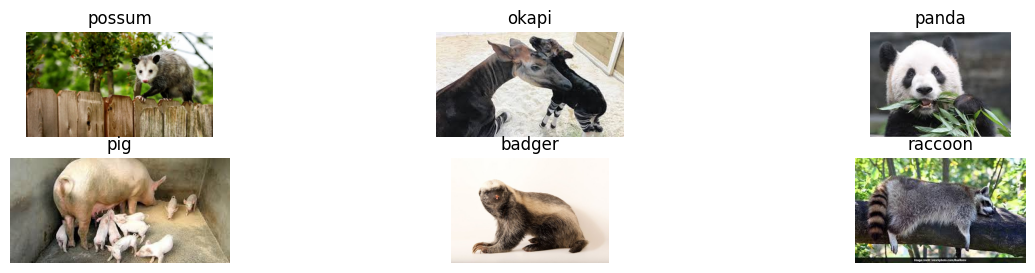

In [12]:
plt.figure(figsize=(15, 3))
for i in range(6):
    plt.subplot(2, 3, i+1)
    image_path = random.choice(images_path)
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(image_path.split("/")[3])
    plt.axis("off")

In [13]:
from pathlib import Path
class ImageDataset(Dataset):
    def __init__(self, all_images_paths, all_classes_name, transform=None):
        self.images = all_images_paths
        self.classes = all_classes_name

        if transform is not None:
            self.transform = transform
        else:
            self.transform = v2.Compose([
                v2.Resize(256),
                v2.CenterCrop(224),
                v2.RandomHorizontalFlip(),
                v2.RandomRotation(degrees=20),
                v2.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2,
                    hue=0.1
                ),
                v2.ToImage(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

        self.classes_to_ids = {self.classes[i]: i for i in range(len(self.classes))}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label_name = Path(image_path).parent.name

        try:
            label_num = self.classes_to_ids[label_name]
        except KeyError:
            raise ValueError(f"Unknown class: {label_name}")

        img = Image.open(image_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label_num


In [17]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

class CLIPDataste(Dataset):
    def __init__(self, all_images, classes, captions, tokenizer):
        self.all_images = ImageDataset(all_images, classes)
        self.captions = captions
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, index):

        images, _ = self.all_images[index]
        caption = self.captions[index]['caption']

        tokens = tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=16,
            return_tensors="pt"
        )

        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        return images, input_ids, attention_mask
        

In [18]:
import json

with open("../data/dataset_captions.json", "r", encoding="utf-8") as file:
    data = json.load(file)

dataset = CLIPDataste(images_path, classes, data, tokenizer)

In [19]:
img, input_ids, attention = dataset[0]

tensor([ 101, 1037, 5099, 6873, 1999, 1996, 2300,  102,    0,    0,    0,    0,
           0,    0,    0,    0])

In [ ]:
from torchvision import models
from transformers import AutoModel

class ImageEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        model_weights = models.EfficientNet_B0_Weights.DEFAULT
        self.backbone = models.efficientnet_b0(weights=model_weights)

        for params in self.backbone.parameters():
            params.requires_grad = False

        self.num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()


        self.embedding_head = nn.Sequential(
            nn.Linear(self.num_features, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.embedding_head(features)

class TextEmbeddingTower(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.num_dims = num_dims

        self.text_encoder_model = AutoModel.from_pretrained("distilbert-base-uncased")
        self.num_bert_feature = self.text_encoder_model.config.hidden_size

        for params in self.text_encoder_model.parameters():
            params.requires_grad = False

        self.text_projection = nn.Sequential(
            nn.Linear(self.num_bert_feature, self.num_dims),
            nn.LayerNorm(self.num_dims)
        )

    def mean_pooling(self, last_hidden_state, attention_mask):

        input_mask_expanded = (
            attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        )

        sum_embedding = torch.sum(last_hidden_state * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embedding / sum_mask

    def forward(self, input_ids, attention_mask):
        text_outputs = self.text_encoder_model(input_ids, attention_mask)
        pooled_output = self.mean_pooling(last_hidden_state=text_outputs.last_hidden_state, attention_mask=attention_mask)

        projected_embd = self.text_projection(pooled_output)

        return projected_embd

class CLIPModel(nn.Module):
    def __init__(self, num_dims):
        super().__init__()
        self.image_tower = ImageEmbeddingTower(num_dims)
        self.text_tower = TextEmbeddingTower(num_dims)

    def forward(self, x, input_ids, attention_mask):
        image_embedding = self.image_tower(x)
        text_embedding = self.text_tower(input_ids, attention_mask)

        img_norm = F.normalize(image_embedding, p=2, dim=-1)
        text_norm = F.normalize(text_embedding, p=2, dim=-1)
        return img_norm, text_norm
    


class ClipLoss(nn.Module):
    def __init__(self, init_temp=0.07):
        super().__init__()
        self.loss = nn.CrossEntropyLoss()
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / init_temp))

    def forward(self, img_emb, text_emb):

        logit_scale = torch.clamp(self.logit_scale.exp(), dtype=torch.float32)
        logits = logit_scale * (img_emb @ text_emb.T)

        batch_size = img_emb.shape[0]
        targets = torch.arange(batch_size, device=img_emb.device)

        loss_img = self.loss(logits, targets)
        loss_text = self.loss(logits.T, targets)

        return (loss_img + loss_text) / 2

        